### **Middleware**

#### Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
##### . Tracking agent behavior with logging, analytics, and debugging.
##### . Transforming prompts, tool selection, and output formatting.
##### . Adding retries, fallbacks, and early termination logic.
##### . Applving rate limits quardrails and PII detection

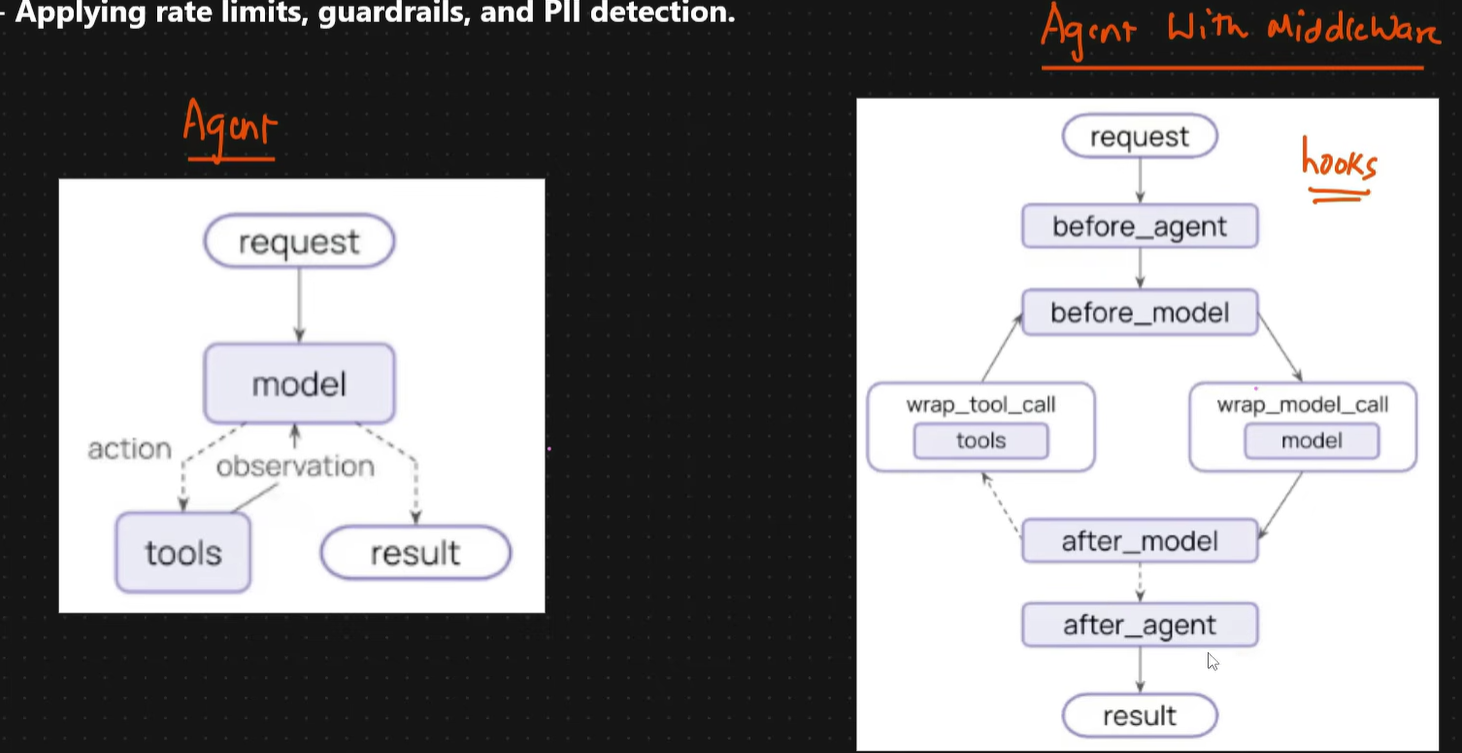

### **Summarization Middleware**
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older
context. Summarization is useful for the following:

. Long-running conversations that exceed context windows.
. Multi-turn dialogues with extensive history.
. Applications where preserving full conversation context matters.

### Trigger based on Messages

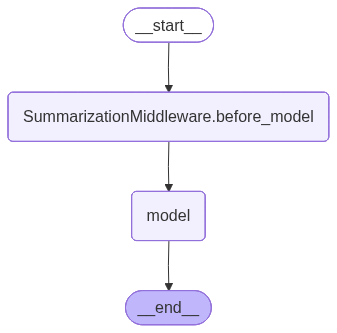

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

### Messagebased summarization
agent=create_agent(
    model= "google_genai:gemini-3.1-flash-lite",
    checkpointer= InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model= "google_genai:gemini-3.1-flash-lite",
            trigger= ("messages", 10),         # If Input+Output= 10 
            keep= ("messages", 4)              # Keep recent top 4 input+output message memory only
        )
    ]
)
agent

In [3]:
### Run with thread ID: Uniquely identifies a User
config= {"configurable": {"thread_id": "test-1"}}

#### **NOTE:** 
#### Here is why we need to pass a dictionary {"messages": [...]} to agent.invoke(...) instead of passing the HumanMessage directly:
#### agent is a LangGraph Graph, not a raw LLM
#### When you call model.invoke(...) on a raw chat model (like ChatGoogleGenerativeAI), you can pass a list of messages or a HumanMessage directly because the model only expects messages.
#### However, the agent object created by create_agent is a compiled LangGraph State Graph.

In [4]:
# Alternative test data
questions=[
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response= agent.invoke( {
            "messages": [HumanMessage(content= q)]
        }, 
        config  
    )
    print(f"Messages: { response["messages"] }")
    print(f"Messages: { len( response['messages'] ) }")

Messages: [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='84c3b110-6130-4085-9b23-c1b950f9d025'), AIMessage(content=[{'type': 'text', 'text': '2 + 2 = 4', 'extras': {'signature': 'EjQKMgEMOdbHo3dDzoBMPZ5aN5Rrui+e0vbspHxA7K5qBePqMDLvDQtepARCtsZhz0wzCwvf'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ebd67-72d8-72e0-a02e-d9792da3fa7d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 7, 'total_tokens': 15, 'input_token_details': {'cache_read': 0}})]
Messages: 2
Messages: [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='84c3b110-6130-4085-9b23-c1b950f9d025'), AIMessage(content=[{'type': 'text', 'text': '2 + 2 = 4', 'extras': {'signature': 'EjQKMgEMOdbHo3dDzoBMPZ5aN5Rrui+e0vbspHxA7K5qBePqMDLvDQtepARCtsZhz0wzCwvf'}}], additional_kwargs={}, re

### Trigger based on Tokens

In [28]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool 

@tool
def HotelBooking(city:str)->str:
    """Search hotels-returns long responses to use more tokens"""    

    return f"""Hotels in {city}
        1. Grand Hotel - 5 star, $350/night, spa, pool, gym
        2. City Inn - 4 star, $180/night, business center
        3. Budget Stay - 3 star, $75/night, free wifi    
    """

agent= create_agent(
    model= "google_genai:gemini-3.1-flash-lite",     
    tools= [HotelBooking],
    checkpointer= InMemorySaver(),
    middleware=[
        SummarizationMiddleware(           
            model= "google_genai:gemini-2.5-flash",
            trigger= ("tokens", 550),
            keep= ("tokens", 200)
        )    
    ]
)

In [29]:
config= {"configurable":{"thread_id": "test-2"}}

# Approx. Token Counter
def count_tokens(messages):
    total_chars= sum( len(str(m.content)) for m in messages )
    return total_chars // 4     # 4 chars = 1 token

In [ ]:
cities= [ 'Paris', 'London', 'Tokyo', 'New York', 'Dubai', 'Singapore' ]

for city in cities:
    response= agent.invoke(
        { 
            "messages": [ HumanMessage(content= f"Find Hotels in {city}") ] },
            config= config
    )

    tokens= count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, { len(response["messages"]) } messages")
    print(f"{response["messages"][-1].content}")

Paris: ~147 tokens, 4 messages
[{'type': 'text', 'text': 'Here are some hotel options in Paris:\n\n*   **Grand Hotel**: 5-star, $350/night, includes a spa, pool, and gym.\n*   **City Inn**: 4-star, $180/night, features a business center.\n*   **Budget Stay**: 3-star, $75/night, includes free Wi-Fi.', 'extras': {'signature': 'EjQKMgEMOdbH9wxrZjFUPcBgt0ybQlOiYMasqakvrsl42qnQ2wp3vfOAGTxmYPCUKZ/K24Ye'}}]
London: ~295 tokens, 8 messages
[{'type': 'text', 'text': 'Here are some hotel options in London:\n\n*   **Grand Hotel**: 5-star, $350/night, includes a spa, pool, and gym.\n*   **City Inn**: 4-star, $180/night, features a business center.\n*   **Budget Stay**: 3-star, $75/night, includes free Wi-Fi.', 'extras': {'signature': 'EjQKMgEMOdbHAMv7yifCoLW3laztDU+25HB1oR8fELl/ROHQ/UM8zGi3NuHJbp0EZiAALk6a'}}]
Tokyo: ~443 tokens, 12 messages
[{'type': 'text', 'text': 'Here are some hotel options in Tokyo:\n\n*   **Grand Hotel**: 5-star, $350/night, includes a spa, pool, and gym.\n*   **City Inn**:

**Accessing Dictionary particular key value pairs**

In [36]:
list_items = response["messages"][-1].content[0]
# print(list_items)
print(list(list_items.items())[1])  

('text', "Here are the hotel options for Singapore:\n\n*   **Grand Hotel**: 5-star, $350/night, features a spa, pool, and gym.\n*   **City Inn**: 4-star, $180/night, features a business center.\n*   **Budget Stay**: 3-star, $75/night, includes free Wi-Fi.\n\nWould you like more details on any of these, or is there another city you'd like to check?")


### Trigger based on Fractions

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
# MTCM => Models, tools, checkpointer, Middleware
agent= create_agent(
    model= "google_genai:gemini-3.1-flash-lite",
    tools= [search_hotels],
    checkpointer= InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="google_genai:gemini-3.1-flash-lite",
            trigger=("fraction", 0.005),    # 0.5% = 640 tokens
            keep=("fraction", 0.002)        # 0.2% = 256 tokens
        )
    ]
)

In [ ]:
config= {"configurable": {"thread_id": "test-3"}}

In [ ]:
# Token counter
def count_tokens (messages) :
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent. invoke(
        {
            "messages": [HumanMessage(content=f"Hotels in {city}")]
        },
        config=config
    )
    tokens = count_tokens(response[ "messages"])
    fraction = tokens / 128000      
    print(f"{city}: ~{tokens} tokens ({fraction: .4%}), {len(response['messages' ])} msgs")
    print(response['messages' ])

Paris: ~89 tokens ( 0.0695%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='870ecaf7-6ccd-494b-be1a-ff6872e504e5'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_hotels', 'arguments': '{"city": "Paris"}'}, '__gemini_function_call_thought_signatures__': {'YILl5a1A': 'EjQKMgEMOdbHCs3B2HHaofTOHd9dxNWT/nBqxzwRJaQEtdlk7x68iDH+3GysuDgbxx9BguJ0'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e8472-4d65-7a41-b5fc-58fb455a79fe-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'YILl5a1A', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 16, 'total_tokens': 61, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='Hotels in Paris: Grand Hotel $350, City Inn $180, Budget Stay $75', name='search_hotels', id='ebf814fe-2c5e-4576-

### **Model Fallback**

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelFallbackMiddleware

agent = create_agent(
    model="gemini-3.1-flash",
    tools=[],
    middleware=[
        ModelFallbackMiddleware(
            "gemini-2.5-flash-lite",
            "gemini-3.1-flash-lite",
        ),
    ],
)

### **Human In the Loop MiddleWare**

#### Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
#### . High-stakes operations requiring human approval (e.g. database writes, financial transactions).
#### . Compliance workflows where human oversight is mandatory.
#### . Long-running conversations where human feedback guides the agent.

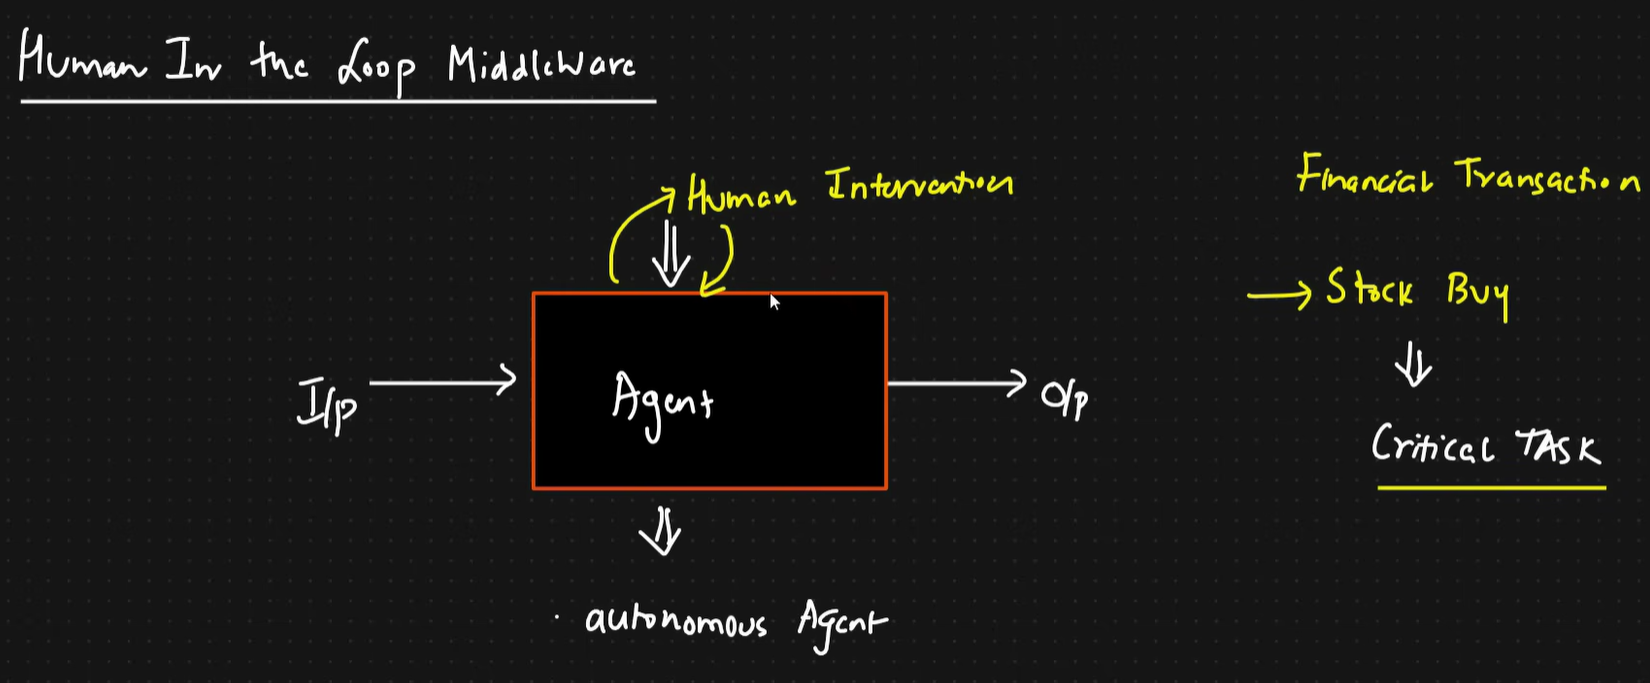

### **TARD=> Tool, Agent Creation, Response, Decision on Interrupt**

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool

def read_email_tool(email_id:str)->str:
    """Mock function to read an email by its ID"""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient:str, subject:str, body:str)-> str:
    """Mock function to send an email"""
    return f"Email sent to {recipient} with subject '{subject}'"

In [ ]:
## MTCM => Model, Tool, Checkpointer, Middleware 
agent= create_agent(
    model= "google_genai:gemini-3.1-flash-lite",
    tools= [read_email_tool, send_email_tool],
    checkpointer= InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions": ["approve", "edit", "reject"] 
                },
                "read_email_tool": False    # Means No HITL required
            }
        )
    ]
)

### **List-> Index, Dictionary-> Key value, Object-> .value**

In [ ]:
config= { "configurable": {"thread_id": "test-approve"}}
response = agent.invoke(
    {
        "messages": [ HumanMessage( content= "Send email to john@test.com with subject 'Hello' and body 'How are you?" ) ] 
    },
    config= config
)

response
# response["messages"][2].content
# response["messages"][3].content[0]['text']

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?", additional_kwargs={}, response_metadata={}, id='9f393302-f3d0-4013-8156-d2fd8098747d'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"recipient": "john@test.com", "subject": "Hello", "body": "How are you?"}'}, '__gemini_function_call_thought_signatures__': {'ibZNCwRm': 'EjQKMgEMOdbH26kueV9r36QK6i8UEtwv0v97OYCrMvNzP/qlczN+83gI6gdZffWwyTzzgeTB'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e8489-b044-7481-8edc-80219d363b2e-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'ibZNCwRm', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'output_tokens': 37, 'total_tokens': 179, 'input_token_details': {

### Approving the Message

In [ ]:
from langgraph.types import Command

if "__interrupt__" in response:
    print("⏸️ Paused! Approving...")

    response= agent.invoke(
        Command(
            resume={
                "decisions": [
                    { "type": "approve" }
                ]
            }
        ),
        config= config
    )

    print(f"✅ Result: {response["messages"][-1].content }")

# print(f"✅ Result: {response["messages"][-1].content[0]['text'] }")


⏸️ Paused! Approving...
✅ Result: [{'type': 'text', 'text': "OK. I've sent the email to john@test.com.", 'extras': {'signature': 'EjQKMgEMOdbHX74aBIcFXXkmOuqrHCHxRYk+QduVAIhvX/nG3xLwRN6XVj0UYo8Bojd3MqUw'}}]


### Rejecting the Message

In [ ]:
config= { "configurable": {"thread_id": "test-reject"}}
response = agent.invoke(
    {
        "messages": [ HumanMessage( content= "Send email to john@test.com with subject 'Hello' and body 'How are you?" ) ] 
    },
    config= config
)

from langgraph.types import Command

if "__interrupt__" in response:
    print("Paused! Rejecting")

    agent.invoke(
        Command(
            resume= {
                "decisions":[
                    { "type": "reject" }
                ] 
            }
        ),
        config= config
    )

    print(response["messages"])      # Output is printed with history values too

Paused! Rejecting
[HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?", additional_kwargs={}, response_metadata={}, id='be09520e-99cb-476d-8438-d22d8fc8fd39'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"subject": "Hello", "body": "How are you?", "recipient": "john@test.com"}'}, '__gemini_function_call_thought_signatures__': {'rlSuWLy3': 'EjQKMgEMOdbHOL82epLNYRVGbgAwyuurkfs/rHz889HkbZFrk/nCvBXQvX/XnCHZvgjmEo+M'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e8491-6186-7413-9796-9aeb6ce3da1a-0', tool_calls=[{'name': 'send_email_tool', 'args': {'subject': 'Hello', 'body': 'How are you?', 'recipient': 'john@test.com'}, 'id': 'rlSuWLy3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'output_tokens': 37, 'total_tokens': 179, 'input_token_details'

### Editing the Message

In [ ]:
config= {"configurable": {"thread_id":"test-edit" } }

response= agent.invoke(
    {
       "messages": [ HumanMessage(content= "Send this email to wrong@gmail.com with subject 'Hello' and body 'hey'") ]
    },
    config= config
)

from langgraph.types import Command

if "__interrupt__" in response:
    print("⏸️Paused! Editing!!")

    response= agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action":{
                            "name":"send_email_tool",
                            "args":{
                                "recipient": input("Enter correct email"),
                                "subject": input("Enter correct subject"),
                                "body": input("Enter correct body"),
                            }
                        }
                    }
                ]
            }
        ),
        config= config
    )

response["messages"]              # With history values

⏸️Paused! Editing!!


[HumanMessage(content="Send this email to wrong@gmail.com with subject 'Hello' and body 'hey'", additional_kwargs={}, response_metadata={}, id='fc18d4ce-61a2-45d1-b8e7-f4180911d159'),
 AIMessage(content=[], additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"recipient": "wrong@gmail.com", "body": "hey", "subject": "Hello"}'}, '__gemini_function_call_thought_signatures__': {'4cmpPAAy': 'EjQKMgEMOdbHJMxs0cgkMHe73LwMgoAPLGER1SyFbtcBxmEgRKVRHlWMCUwNK8CZeEnxT5PZ'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e84d4-61fb-72b2-b591-1b7c220fe745-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'patilratish369@gmail.com', 'subject': 'hello', 'body': 'hey'}, 'id': '4cmpPAAy', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 141, 'output_tokens': 34, 'total_tokens': 175, 'input_token_details': {'cache_read': 0}}),
